In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Load Diabetes Dataset

In [36]:
# Load dataset
df=pd.read_csv('Dataset of Diabetes .csv')
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


### Analyses the Dataset

In [37]:
# Check dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 109.5 KB


In [38]:
df.head(10)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,634,34224,F,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,721,34225,F,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
7,421,34227,M,48,4.7,47,4.0,2.9,0.8,0.9,1.6,0.4,24.0,N
8,670,34229,M,43,2.6,67,4.0,3.8,0.9,2.4,3.7,1.0,21.0,N
9,759,34230,F,32,3.6,28,4.0,3.8,2.0,2.4,3.8,1.0,24.0,N


In [39]:
# Numerical columns
num_cols=df.select_dtypes(include=[np.number]).drop(columns=['ID', 'No_Pation']).columns.to_list()
num_cols

['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

In [40]:
# Describe all numerical columns without 'ID', 'No_Pation'
df[num_cols].describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


### Drop 'ID' & 'No_Pation' columns

In [41]:
df=df.drop(columns=['ID', 'No_Pation'])
df.head()


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Analyses the string columns & Data Cleaning

In [42]:
# Gender is a sting columns so check the unique value of gender
print(f'unique values:{df['Gender'].unique()}') 
print(f'number of unique values: {df['Gender'].nunique()}')
print(f'Value Count: {df['Gender'].value_counts()}')

unique values:<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str
number of unique values: 3
Value Count: Gender
M    565
F    434
f      1
Name: count, dtype: int64


In [43]:
# Change data lowercase to uppercase
df['Gender']=df['Gender'].str.upper()
print(f'unique values:{df['Gender'].unique()}') 
print(f'number of unique values: {df['Gender'].nunique()}')
print(f'Value Count: {df['Gender'].value_counts()}')

unique values:<StringArray>
['F', 'M']
Length: 2, dtype: str
number of unique values: 2
Value Count: Gender
M    565
F    435
Name: count, dtype: int64


In [44]:
# CLASS is a sting columns so check the unique value of CLASS
print(f'unique values:{df['CLASS'].unique()}') 
print(f'number of unique values: {df['CLASS'].nunique()}')
print(f'Value Count: {df['CLASS'].value_counts()}')

unique values:<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str
number of unique values: 5
Value Count: CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64


In [45]:
#Remove whitespace 
df['CLASS']=df['CLASS'].str.strip()
print(f'unique values:{df['CLASS'].unique()}') 
print(f'number of unique values: {df['CLASS'].nunique()}')
print(f'Value Count: {df['CLASS'].value_counts()}')

unique values:<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
number of unique values: 3
Value Count: CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


In [46]:
# Check Duplicates
print(df.duplicated().sum())
print(df.shape)

174
(1000, 12)


In [47]:
df=df.drop_duplicates().reset_index(drop=True)
df.shape

(826, 12)

### Identify the features and target values

In [48]:
# Define feature and target columns
target='CLASS'
X=df.drop(columns=[target])
y=df[target]

In [49]:
X

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0
3,F,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0
4,F,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0
...,...,...,...,...,...,...,...,...,...,...,...
821,F,57,4.1,70,9.3,5.3,3.3,1.0,1.4,1.3,29.0
822,M,55,3.1,39,8.5,5.0,2.5,1.9,2.9,0.7,27.0
823,M,28,3.5,61,8.5,4.5,1.9,1.1,2.6,0.8,37.0
824,M,69,10.3,185,7.7,4.9,1.9,1.2,3.0,0.7,37.0


In [50]:
y

0      N
1      N
2      N
3      N
4      N
      ..
821    Y
822    Y
823    Y
824    Y
825    Y
Name: CLASS, Length: 826, dtype: str

In [51]:
# Y-> diabetic, N-> non-diabetic, P-> pre-diabetic
print(y.value_counts(normalize=True) * 100)

CLASS
Y    83.535109
N    11.622276
P     4.842615
Name: proportion, dtype: float64


### Data Visualization of Target values

Text(0, 0.5, 'Count')

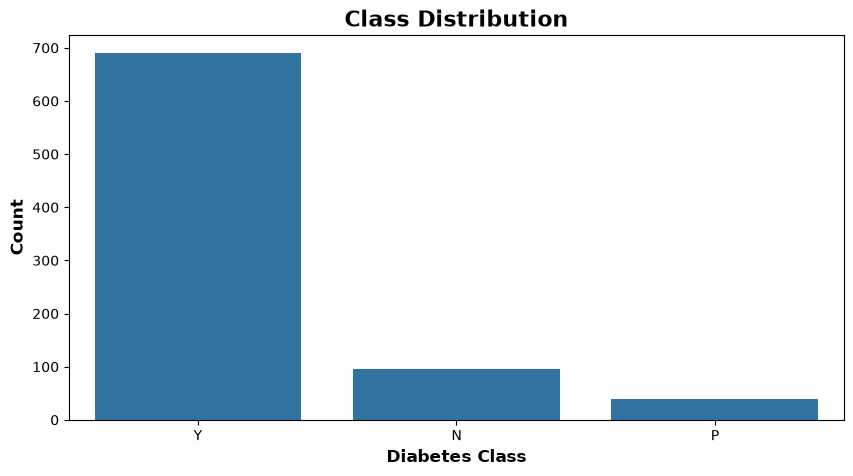

In [52]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x=target, order=y.value_counts().index)
plt.title('Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')


### Visualize features vs target

In [53]:
num_cols

['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

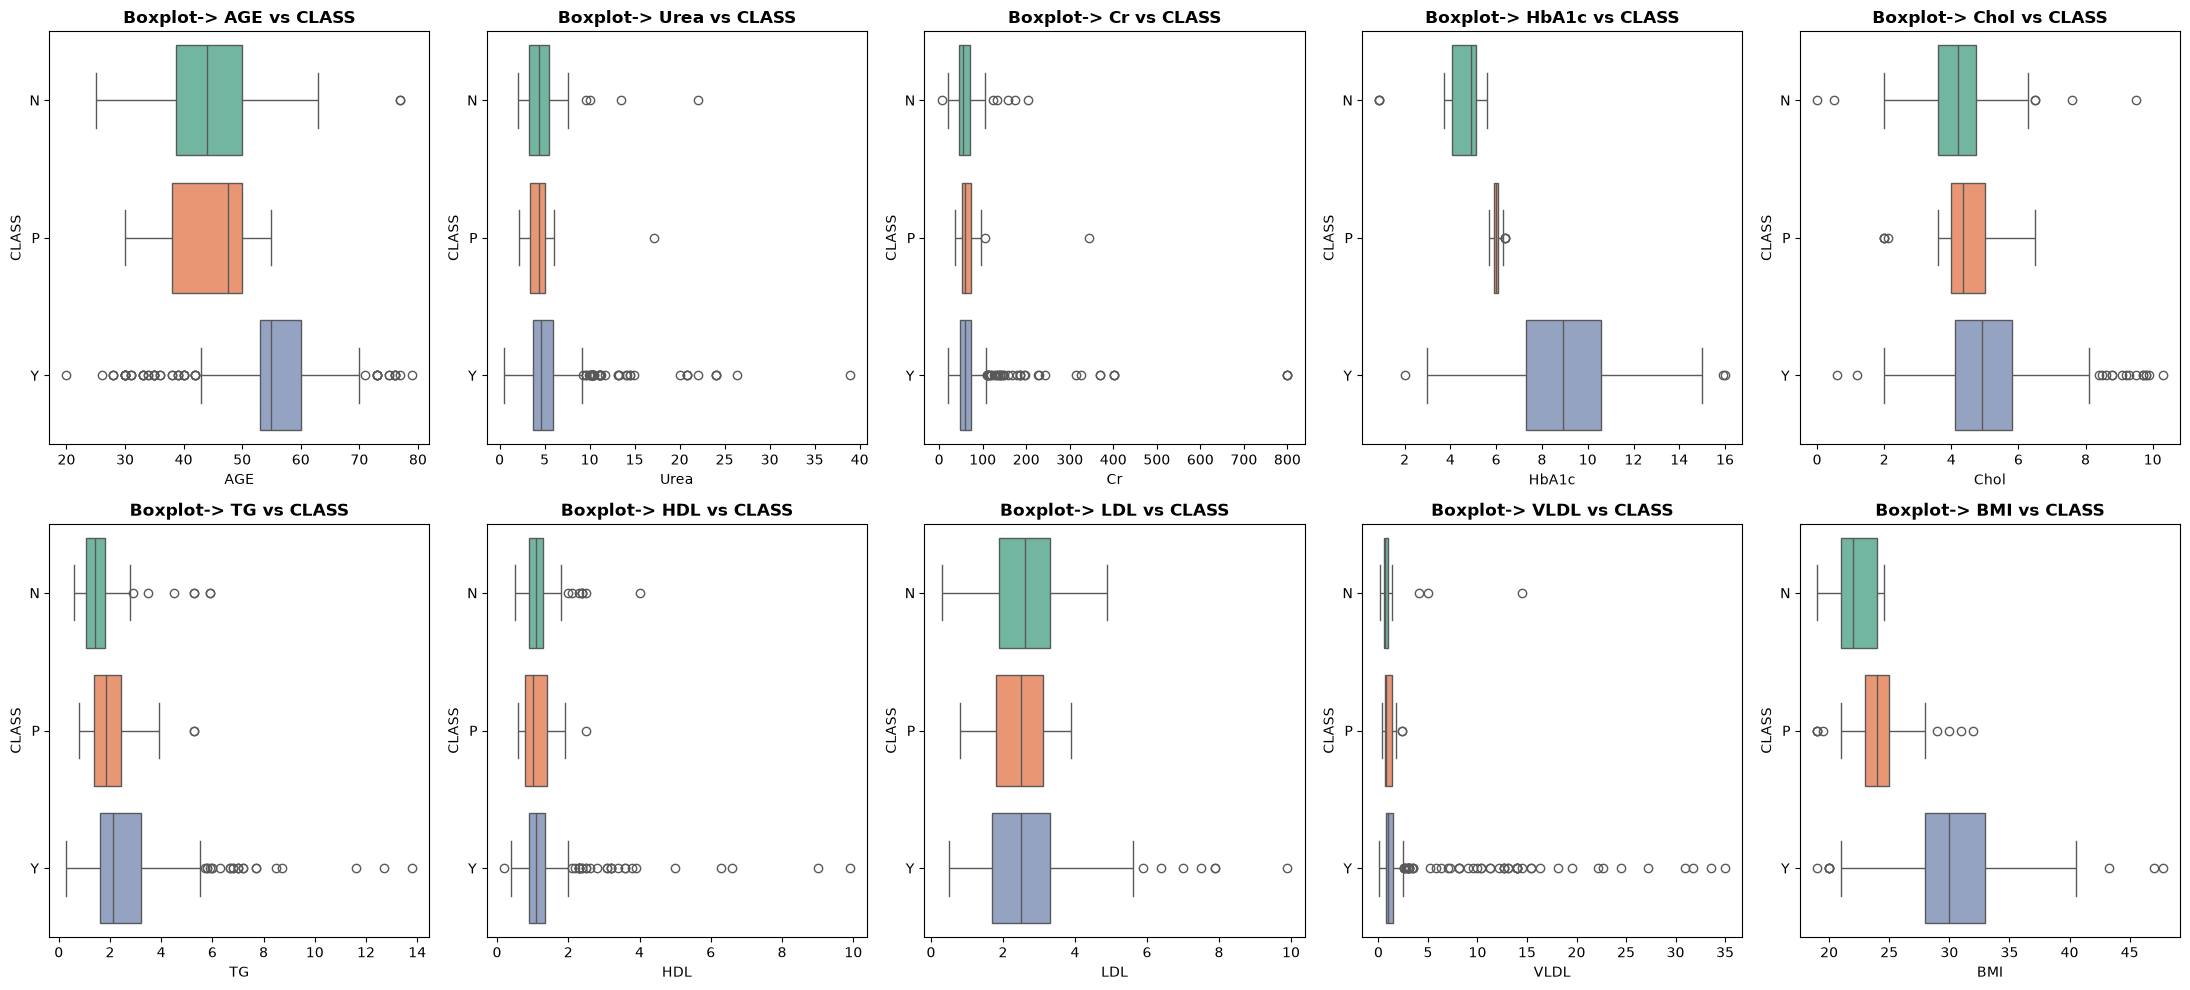

In [54]:
fig, ax=plt.subplots(2,5,figsize=(22,10))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, y='CLASS', hue='CLASS', ax=ax[i], palette="Set2")
    ax[i].set_title(f'Boxplot-> {col} vs CLASS', fontweight='bold')

plt.tight_layout()
plt.show()


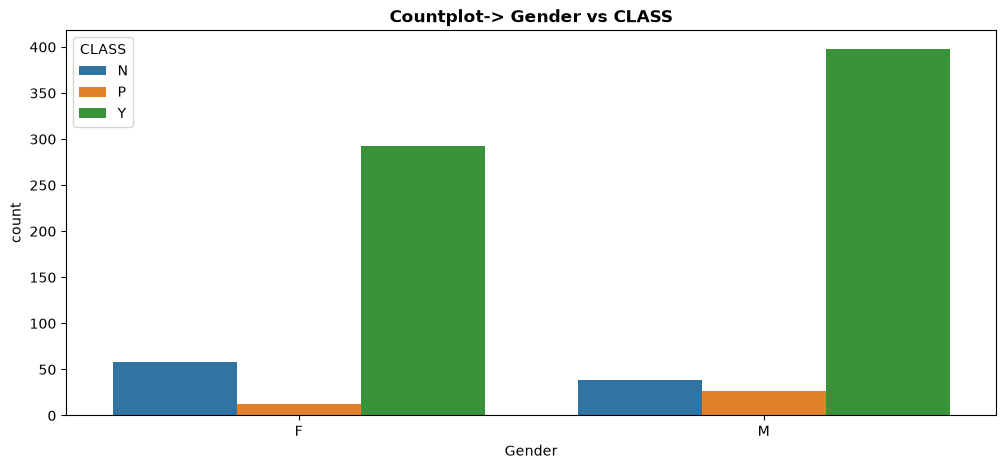

In [55]:
# Gender vs  CLASS
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Gender', hue='CLASS', palette='tab10')
plt.title('Countplot-> Gender vs CLASS', fontweight='bold')
plt.show()

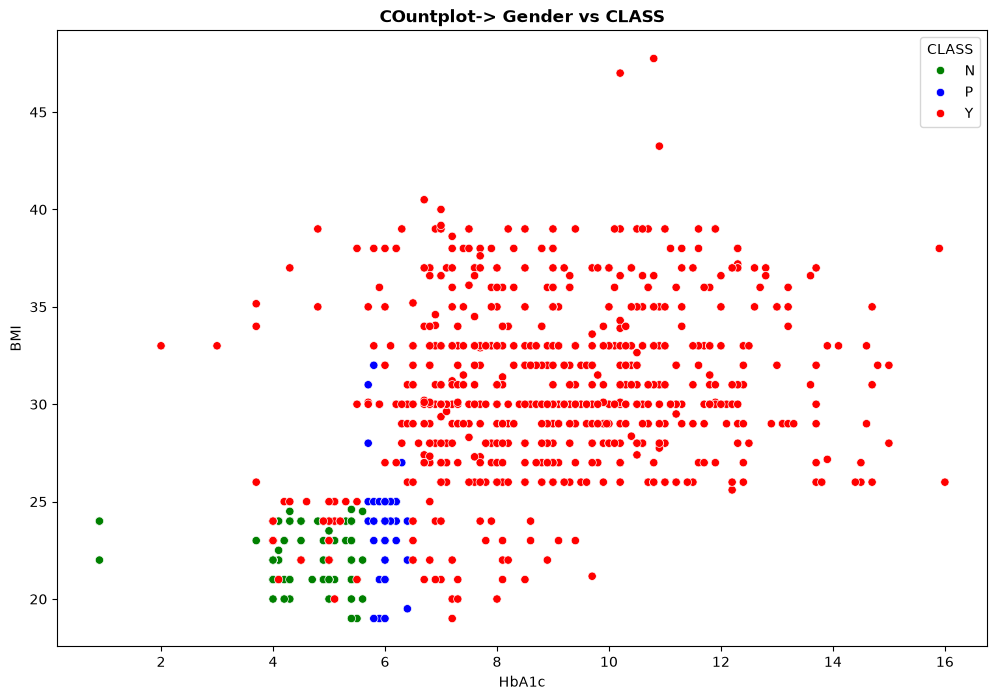

In [56]:
# HbA1c vs BMI 
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='HbA1c', y='BMI',hue='CLASS', palette={'N': 'green', 'P': 'blue', 'Y': 'red'})
plt.title('COuntplot-> Gender vs CLASS', fontweight='bold')
plt.show()

In [57]:
X.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0
3,F,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0
4,F,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0


In [ ]:
# Label encoding for gender -> F-0, M-1
X['Gender'] = LabelEncoder().fit_transform(X['Gender'])
X.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0


### Train Test Split

In [59]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.3, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (578, 11)
Test shape: (248, 11)


### Decision Tree Training

In [60]:
dc_model= DecisionTreeClassifier(class_weight='balanced',max_depth=3,criterion='gini', random_state=42)
dc_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

### Tree Visualization

In [61]:
X_cols=X.columns
tree_rules = export_text(dc_model, feature_names=X_cols)
print("🌳 Decision Tree Rules:")
print(tree_rules)

🌳 Decision Tree Rules:
|--- HbA1c <= 5.65
|   |--- BMI <= 24.80
|   |   |--- VLDL <= 1.45
|   |   |   |--- class: N
|   |   |--- VLDL >  1.45
|   |   |   |--- class: Y
|   |--- BMI >  24.80
|   |   |--- class: Y
|--- HbA1c >  5.65
|   |--- HbA1c <= 6.45
|   |   |--- AGE <= 55.50
|   |   |   |--- class: P
|   |   |--- AGE >  55.50
|   |   |   |--- class: Y
|   |--- HbA1c >  6.45
|   |   |--- class: Y



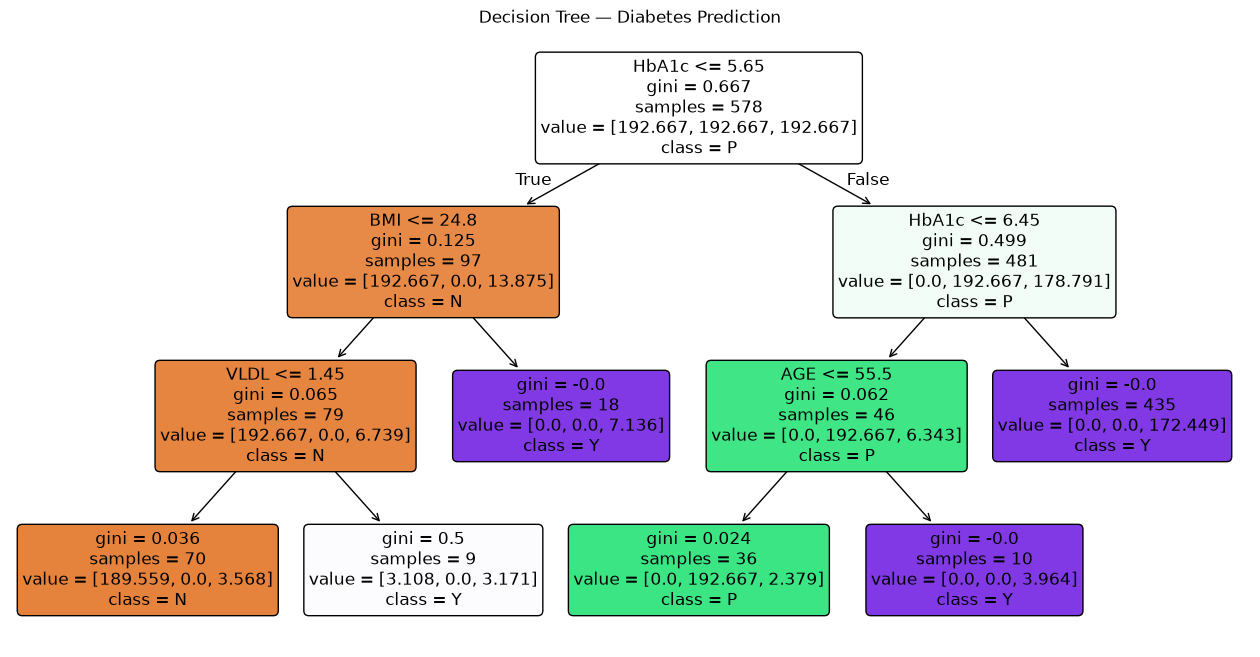

In [62]:
# Tree Visual Plot
plt.figure(figsize=(16,8))
plot_tree(dc_model, feature_names=X_cols, class_names=list(dc_model.classes_), filled=True,rounded=True, fontsize=12)
plt.title("Decision Tree — Diabetes Prediction")
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()

### Data Prediction

In [63]:
y_pred= dc_model.predict(X_test)
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

Predicted: ['Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'N' 'N' 'Y' 'Y' 'N' 'P' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'P' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'P' 'Y' 'N' 'Y' 'N' 'P' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y'
 'P' 'Y' 'N' 'P' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'P' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'P' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'P' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'P' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'P' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'P' 'N'
 'N' 'P' 'Y' 'Y' 'Y' 'P' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y'

### Model Accuracy

In [64]:
# Model Accuracy
accuracy= accuracy_score(y_test, y_pred)
print(f"{accuracy*100:.2f} %")

96.37 %


In [65]:
# Classification Report
cr=classification_report(y_test, y_pred, target_names=dc_model.classes_)
print("Confusion Matrix:\n", cr)

Confusion Matrix:
               precision    recall  f1-score   support

           N       0.91      0.94      0.93        34
           P       0.71      1.00      0.83        10
           Y       0.99      0.97      0.98       204

    accuracy                           0.96       248
   macro avg       0.87      0.97      0.91       248
weighted avg       0.97      0.96      0.96       248



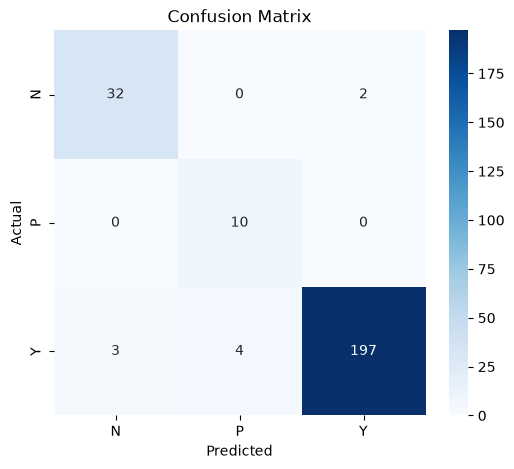

In [66]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=dc_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dc_model.classes_, yticklabels=dc_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()